In [1]:
%pwd
%load_ext autoreload
%autoreload 2

In [2]:
import sys
import os

project_root = os.path.abspath(os.path.join(os.getcwd(), "../../"))
if project_root not in sys.path:
    sys.path.insert(0, project_root)
from experiments.scripts.run_experiments import run_experiment
from experiments.scripts.experiment_utils import generate_experiments

INFO: NumExpr defaulting to 8 threads.


In [3]:
base_config = {
    # Experiment
    "experiment": "VAE_spherical_acosta",
    "random_seed": 42,
    "logging": True,

    # Dataset
    "dataset_name": "s2_synthetic",
    "batch_size": 64,
    "rotation": "random",
    "translation": None,
    "n_times": 2500,
    "embedding_dim": 10,
    "radius": 1,
    "noise_var": 0.001,
    "geodesic_distortion_amp": 0.3,

    # Model
    'model_type': 'VMToroidalVAE',
    'latent_dim': 2,
    'manifold_dim': 2,
    'sftbeta': 4.5,
    'device': "cpu",
    'encoder_widths': [400,400,400,400,400,400],
    'decoder_widths': [200,200,200,200],

    # Optimizer
    "learning_rate": 0.001,

    # Trainer
    'verbose': False,
    'num_epochs': 50,
    'log_interval': 100,
    'recon_loss': "MSE",
    'topo_loss': False,
    'dim_topo_loss': 0,  # Max feature dimension topological loss
    'alpha': 1.0,  # Weight for reconstruction loss
    'beta': 0.03,  # Weight for KL loss
    'gamma': 0.0,  # Weight for topological loss

    # Curvature computation
    "plot_curvatures": True,
    "compute_emp_curv": False,
    "compute_true_curv": True,
    "compute_learned_curv": True,
    "compute_rec_curv": False,
    "quadric_dim": 1,
    "n_plot_points": 2500,
    "n_points_emp_curv": 1000,
    "n_points_pullback_curv": 1000, 
    "k": 110,
    "smoothing": False,

    # Persistent homology
    "persistent_homology": False,
    "n_points_pers_hom": 1000,
    "scale": False,
    "homology_dimensions": [0, 1]
}


param_grid = {
    'num_epochs': [600] * 2,
    'noise_var': [0.0001] * 2,
    'activation': ['softplus'] * 2,
    'beta': [0.03,0.08],
}

all_configs = generate_experiments(base_config, param_grid)


Running exp00_VAE_spherical_acosta. 
Description: num_epochs=600, noise_var=0.0001, activation=softplus, beta=0.03
--------------------------------------------------------------------------------------


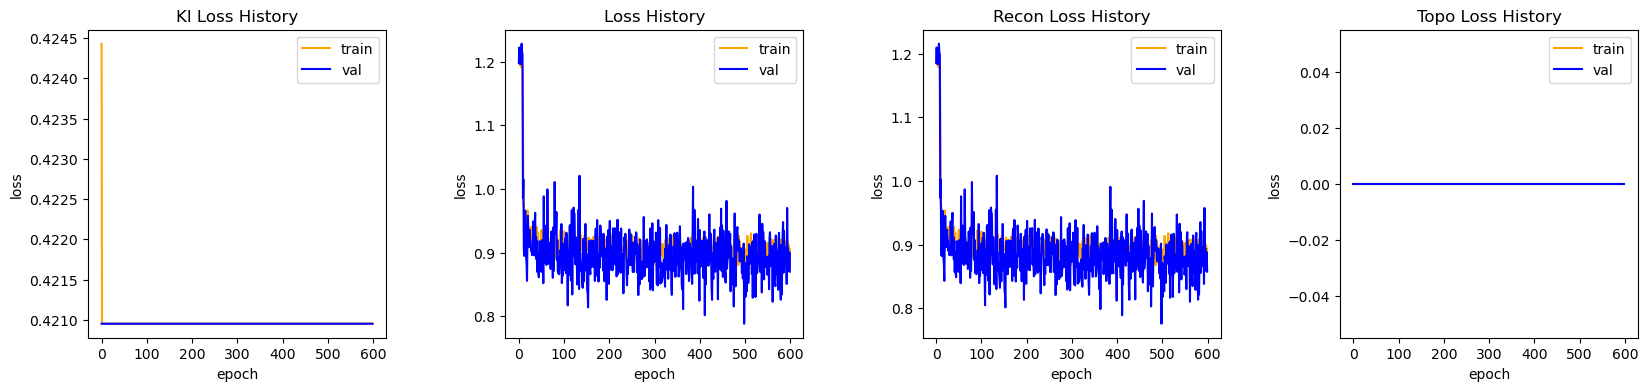

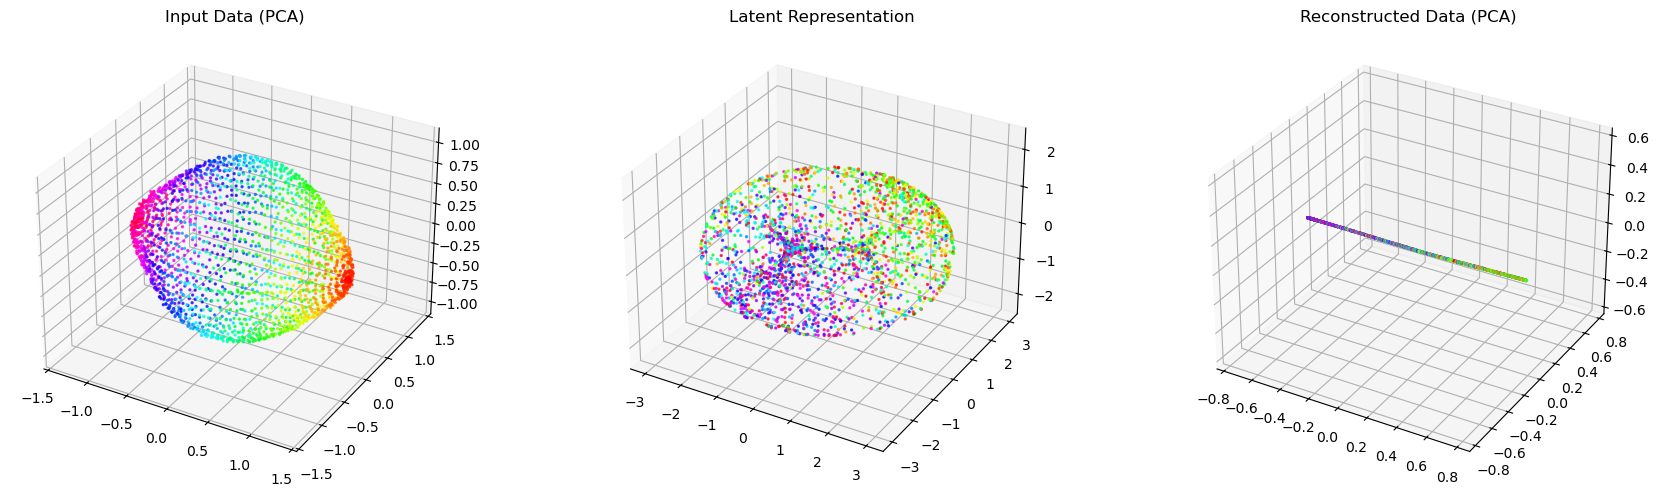

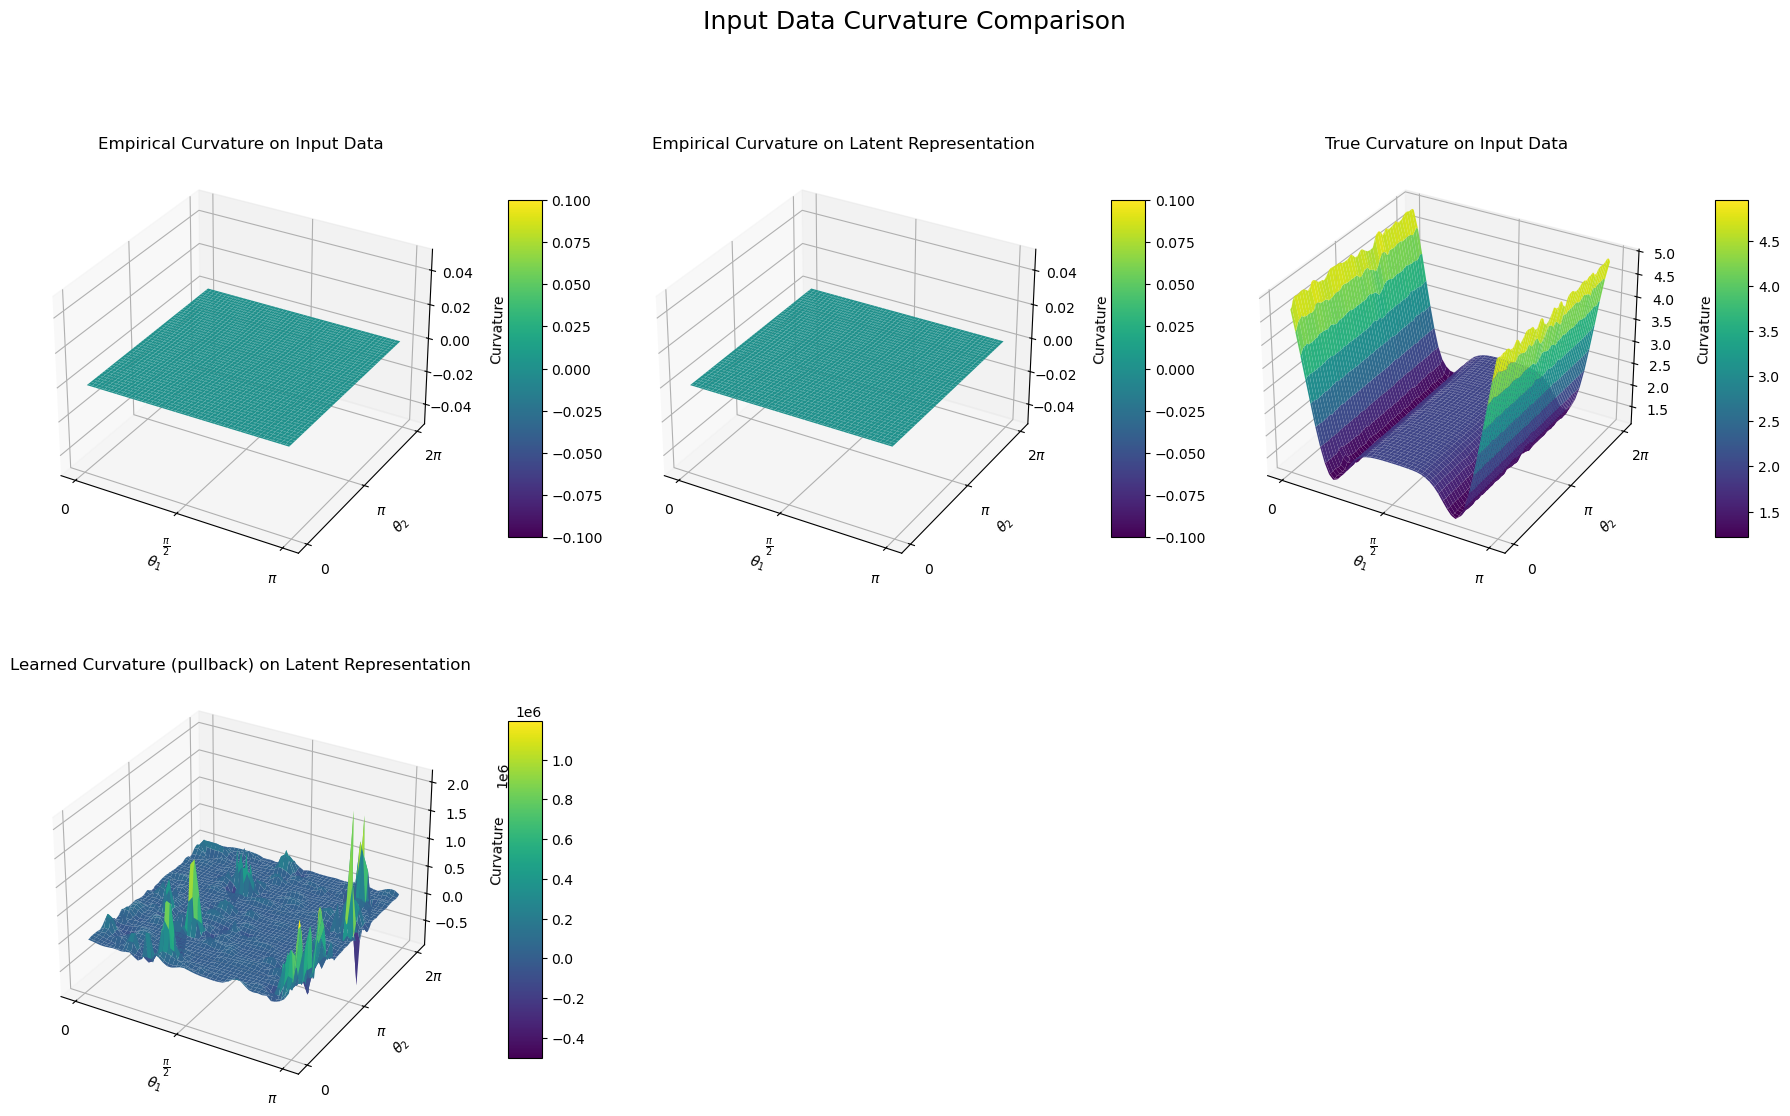

<Figure size 1800x1000 with 0 Axes>

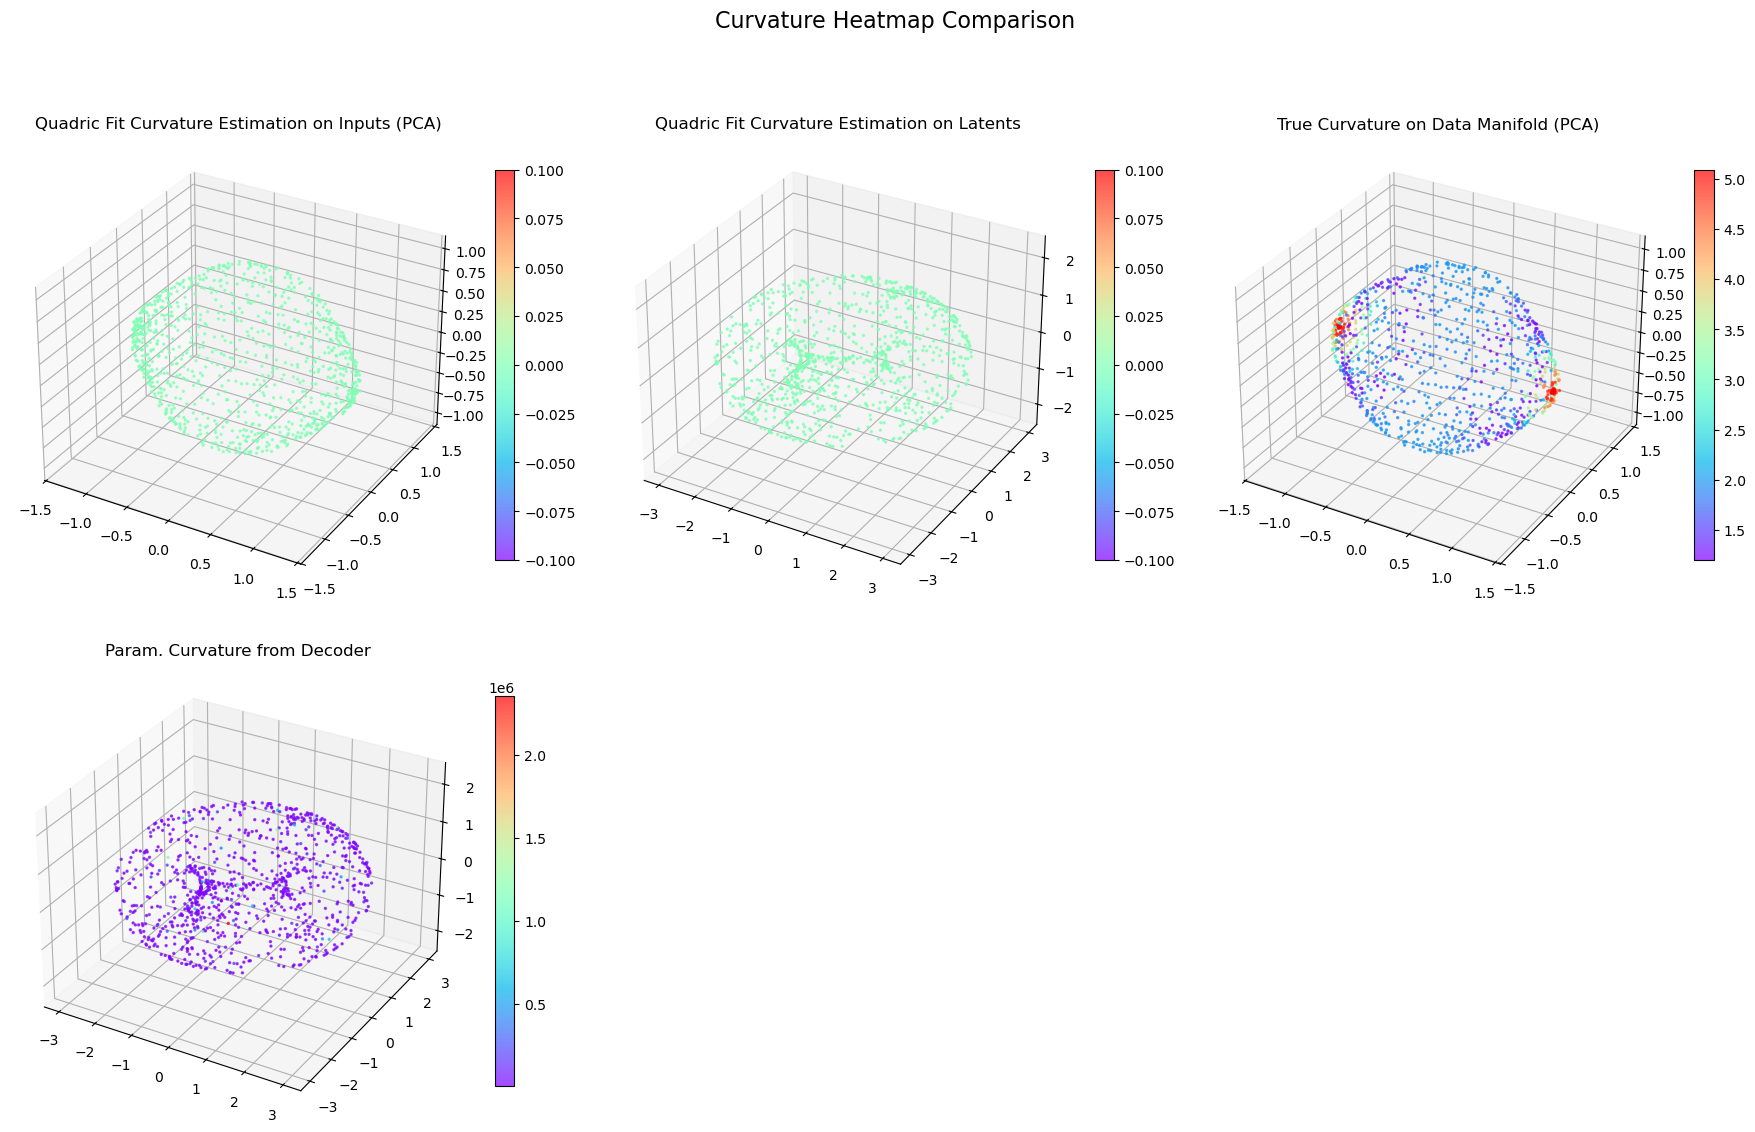

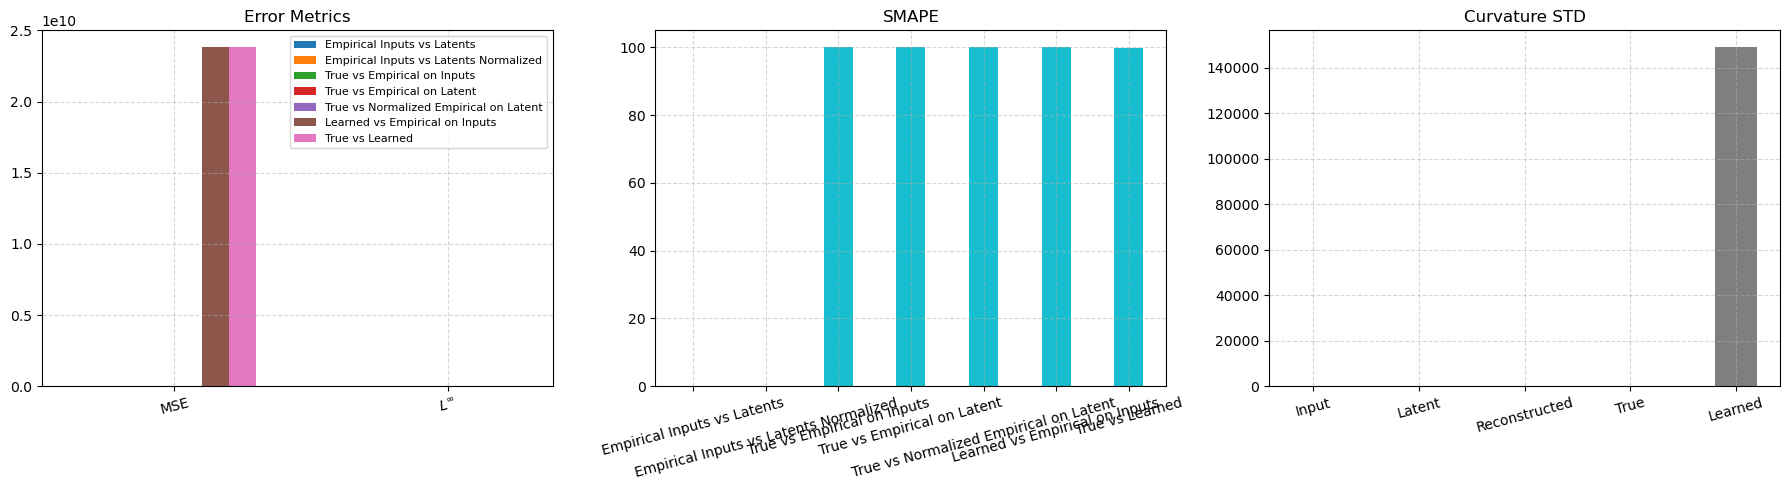

Execution time exp00_VAE_spherical_acosta: 909.7314 seconds

Running exp01_VAE_spherical_acosta. 
Description: num_epochs=600, noise_var=0.0001, activation=softplus, beta=0.08
--------------------------------------------------------------------------------------


KeyboardInterrupt: 

In [4]:
run_experiment(all_configs=all_configs)
